In [1]:
import pandas as pd

# Carrega o arquivo (ajuste o caminho se estiver em uma subpasta)
df_sim = pd.read_parquet('data/processed/sim_2022_unificado.parquet')

# Opção 1: Listar apenas os nomes das colunas (bom para copiar e colar)
print("Lista de Colunas:")
print(df_sim.columns.tolist())

# Opção 2: Ver nomes, tipos de dados e contagem de nulos (Melhor para diagnóstico)
print("\nInformações do DataFrame:")
df_sim.info()

# Opção 3: Ver as primeiras linhas para entender o conteúdo
display(df_sim.head())

Lista de Colunas:
['TIPOBITO', 'DTOBITO', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'CODMUNRES', 'CIRCOBITO', 'CAUSABAS']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544266 entries, 0 to 1544265
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   TIPOBITO   1544266 non-null  object
 1   DTOBITO    1544266 non-null  object
 2   IDADE      1544266 non-null  object
 3   SEXO       1544266 non-null  object
 4   RACACOR    1544266 non-null  object
 5   ESC2010    1544266 non-null  object
 6   CODMUNRES  1544266 non-null  object
 7   CIRCOBITO  1544266 non-null  object
 8   CAUSABAS   1544266 non-null  object
dtypes: object(9)
memory usage: 106.0+ MB


,TIPOBITO,DTOBITO,IDADE,SEXO,RACACOR,ESC2010,CODMUNRES,CIRCOBITO,CAUSABAS
0,2,27012022,469,2,4,2,530010,,I251
1,2,26012022,459,1,4,3,530010,,E789
2,2,05012022,429,1,4,3,530010,,J189
3,2,26012022,491,2,1,1,530010,,J449
4,2,31012022,482,1,4,1,530010,,J449


In [2]:
#Agora vamos pegar o numerador da TMI para 2022
# 1. Filtrar apenas óbitos NÃO fetais
obitos_vivos = df_sim[df_sim['TIPOBITO'] == '2'].copy()

# 2. Converter IDADE para string para ler o primeiro dígito
# O dicionário diz que unidades 0, 1, 2 e 3 são menores de 1 ano
# 0=minutos, 1=horas, 2=dias, 3=meses
obitos_infantis = obitos_vivos[
    obitos_vivos['IDADE'].astype(str).str[0].isin(['0', '1', '2', '3'])
]

# 3. Agrupar por Município de Residência
tmi_numerador = obitos_infantis.groupby('CODMUNRES').size().reset_index(name='obitos_menores_1ano')

# Visualizar
display(tmi_numerador.head())

,CODMUNRES,obitos_menores_1ano
0,110001,2
1,110002,32
2,110004,13
3,110005,1
4,110006,4


In [4]:
import pandas as pd

# Carregando o arquivo (assumindo que o separador é vírgula conforme seu snippet)
# Se der erro de encoding, tente 'latin1'
df = pd.read_csv('data/nascidos_vivos/nascidos_vivos_2022.csv', encoding='latin1', sep=',')

# 1. Renomeando para facilitar a manipulação
# O nome original 'MunicÃ­pio' sugere erro de encoding na origem, vamos padronizar
df.columns = ['Municipio_Completo', 'Nascidos']

# 2. Filtrando: Removemos qualquer linha que contenha "IGNORADO"
# O til (~) inverte a condição, ou seja, "pegue tudo que NÃO contém IGNORADO"
df_clean = df[~df['Municipio_Completo'].str.contains('IGNORADO', na=False)].copy()

# 3. Separando Código e Nome
# O padrão é "110001 ALTA FLORESTA D'OESTE" (Código + Espaço + Nome)
# Usamos o split com n=1 para separar apenas no primeiro espaço
df_clean[['Codigo_IBGE', 'Nome_Municipio']] = df_clean['Municipio_Completo'].str.split(' ', n=1, expand=True)

# 4. Organizando o DataFrame final
df_final = df_clean[['Codigo_IBGE', 'Nome_Municipio', 'Nascidos']]

# Visualizando o resultado
print("Visualização Limpa:")
display(df_final.head())

Visualização Limpa:


,Codigo_IBGE,Nome_Municipio,Nascidos
1,110001,ALTA FLORESTA D'OESTE,368.0
2,110002,ARIQUEMES,1505.0
3,110003,CABIXI,64.0
4,110004,CACOAL,1353.0
5,110005,CEREJEIRAS,272.0


In [5]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. PREPARAÇÃO DO NUMERADOR (SIM - Óbitos)
# ==============================================================================
# Critérios:
# - TIPOBITO == '2' (Não Fetal)
# - IDADE começando com 0 (min), 1 (horas), 2 (dias), 3 (meses)

# Garante que as colunas críticas sejam string para manipulação
df_sim['TIPOBITO'] = df_sim['TIPOBITO'].astype(str)
df_sim['IDADE'] = df_sim['IDADE'].astype(str).str.zfill(3) # Garante 3 dígitos (ex: '025')
df_sim['CODMUNRES'] = df_sim['CODMUNRES'].astype(str)

# Filtro
mask_infantil = (
    (df_sim['TIPOBITO'] == '2') & 
    (df_sim['IDADE'].str[0].isin(['0', '1', '2', '3']))
)

# Agrupamento
# Nota: O SIM geralmente usa 7 dígitos. O comando .str[:6] padroniza para 6.
df_obitos = (
    df_sim[mask_infantil]
    .groupby(df_sim['CODMUNRES'].str[:6])
    .size()
    .reset_index(name='Obitos_Infantis')
    .rename(columns={'CODMUNRES': 'Codigo_IBGE'}) # Renomeia para facilitar o merge
)

# ==============================================================================
# 2. PREPARAÇÃO DO DENOMINADOR (SINASC - Nascidos Vivos)
# ==============================================================================
# Supondo que df_final seja o dataframe limpo do passo anterior
# Colunas esperadas: 'Codigo_IBGE', 'Nascidos'

df_nascidos = df_final.copy()

# Garantia de Tipagem e Padronização (6 dígitos)
df_nascidos['Codigo_IBGE'] = df_nascidos['Codigo_IBGE'].astype(str).str[:6]
df_nascidos['Nascidos'] = pd.to_numeric(df_nascidos['Nascidos'], errors='coerce').fillna(0)

# Agrupa por segurança (caso haja linhas duplicadas do mesmo município)
df_nascidos = (
    df_nascidos
    .groupby('Codigo_IBGE')['Nascidos']
    .sum()
    .reset_index()
)

# ==============================================================================
# 3. MERGE E CÁLCULO (O "Pulo do Gato")
# ==============================================================================

# Left Join: Mantém todos os municípios que tiveram nascimentos
df_tmi = pd.merge(df_nascidos, df_obitos, on='Codigo_IBGE', how='left')

# Preenche com 0 onde não houve óbito (NaN -> 0)
df_tmi['Obitos_Infantis'] = df_tmi['Obitos_Infantis'].fillna(0)

# Cálculo da Taxa
# Fórmula: (Óbitos < 1 ano / Nascidos Vivos) * 1.000
df_tmi['TMI'] = (df_tmi['Obitos_Infantis'] / df_tmi['Nascidos']) * 1000

# ==============================================================================
# 4. LIMPEZA ESTATÍSTICA (Para seu PCA)
# ==============================================================================

# Tratando divisões por zero (infinito)
# Se Nascidos = 0 e Obitos > 0 -> Infinito (Erro de registro temporal)
# Se Nascidos = 0 e Obitos = 0 -> NaN (Indefinido)
df_tmi.replace([np.inf, -np.inf], np.nan, inplace=True)

# Visualização Final
print("Resumo Estatístico da TMI:")
print(df_tmi['TMI'].describe())

print("\nTop 5 Municípios com maiores TMIs (Checagem de Outliers):")
display(df_tmi.sort_values('TMI', ascending=False).head())

# Dica: Para o PCA, considere remover municípios com TMI NaN
# df_pca = df_tmi.dropna(subset=['TMI'])

Resumo Estatístico da TMI:
count    5571.000000
mean       12.917803
std        13.456395
min         0.000000
25%         0.000000
50%        11.029412
75%        18.181818
max       166.666667
Name: TMI, dtype: float64

Top 5 Municípios com maiores TMIs (Checagem de Outliers):


,Codigo_IBGE,Nascidos,Obitos_Infantis,TMI
5085,432255,12.0,2.0,166.666667
5078,432235,7.0,1.0,142.857143
4388,420475,16.0,2.0,125.000000
5560,522157,35.0,4.0,114.285714
868,221037,29.0,3.0,103.448276


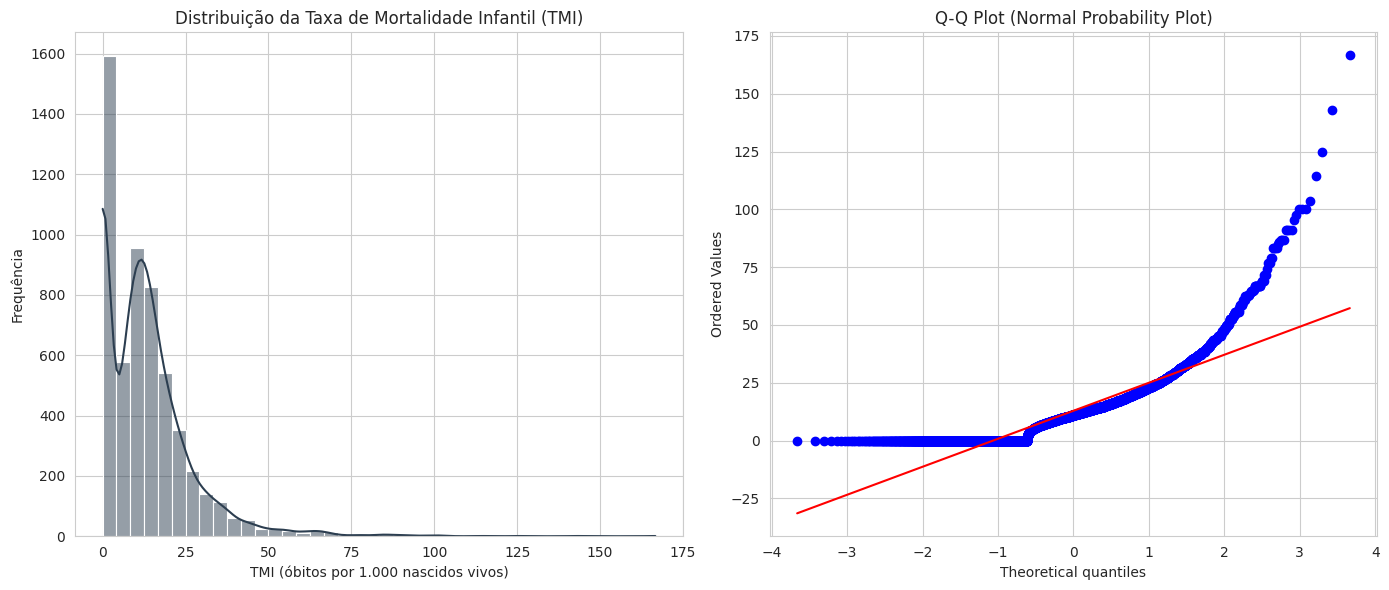


=== Testes de Normalidade (Alpha = 0.10) ===
Teste D'Agostino K²: p-valor = 0.0000e+00
Teste Kolmogorov-Smirnov: p-valor = 8.5832e-139

CONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuração do estilo para publicação
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: Histograma + KDE (Distribuição) ---
plt.subplot(1, 2, 1)
# O 'histplot' mostra a frequência real, o 'kde' a curva suave estimada
sns.histplot(df_tmi['TMI'].dropna(), kde=True, color='#2c3e50', bins=40)
plt.title('Distribuição da Taxa de Mortalidade Infantil (TMI)', fontsize=12)
plt.xlabel('TMI (óbitos por 1.000 nascidos vivos)')
plt.ylabel('Frequência')

# --- GRÁFICO 2: Q-Q Plot (Normalidade) ---
plt.subplot(1, 2, 2)
# Compara os quantis da sua TMI com os quantis teóricos de uma Normal
stats.probplot(df_tmi['TMI'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Normal Probability Plot)', fontsize=12)

plt.tight_layout()
plt.show()

# --- TESTES DE HIPÓTESES (Alpha = 10%) ---
print("\n=== Testes de Normalidade (Alpha = 0.10) ===")
dados_validos = df_tmi['TMI'].dropna()

# 1. Teste de D'Agostino-Pearson (Baseado em Assimetria e Curtose) - Recomendado para N grande
stat_k2, p_k2 = stats.normaltest(dados_validos)
print(f"Teste D'Agostino K²: p-valor = {p_k2:.4e}")

# 2. Teste de Kolmogorov-Smirnov (Comparação de CDFs)
# Normalizamos os dados para comparar com a normal padrão (0,1)
stat_ks, p_ks = stats.kstest((dados_validos - dados_validos.mean())/dados_validos.std(), 'norm')
print(f"Teste Kolmogorov-Smirnov: p-valor = {p_ks:.4e}")

# Conclusão Automática
alpha = 0.10
if p_k2 < alpha:
    print(f"\nCONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.")
else:
    print(f"\nCONCLUSÃO: Falhamos em rejeitar H0. A distribuição pode ser normal.")

In [9]:
# Aplicando o filtro de robustez estatística
df_clean = df_tmi[df_tmi['Nascidos'] >= 100].copy()

# Agora sim, use df_clean para seus gráficos e PCA
print(f"Cidades restantes: {len(df_clean)} de {len(df_tmi)}")
print(df_clean['TMI'].describe())

Cidades restantes: 3300 de 5582
count    3300.000000
mean       13.191310
std         8.317117
min         0.000000
25%         7.934934
50%        12.048193
75%        17.241379
max        64.665127
Name: TMI, dtype: float64


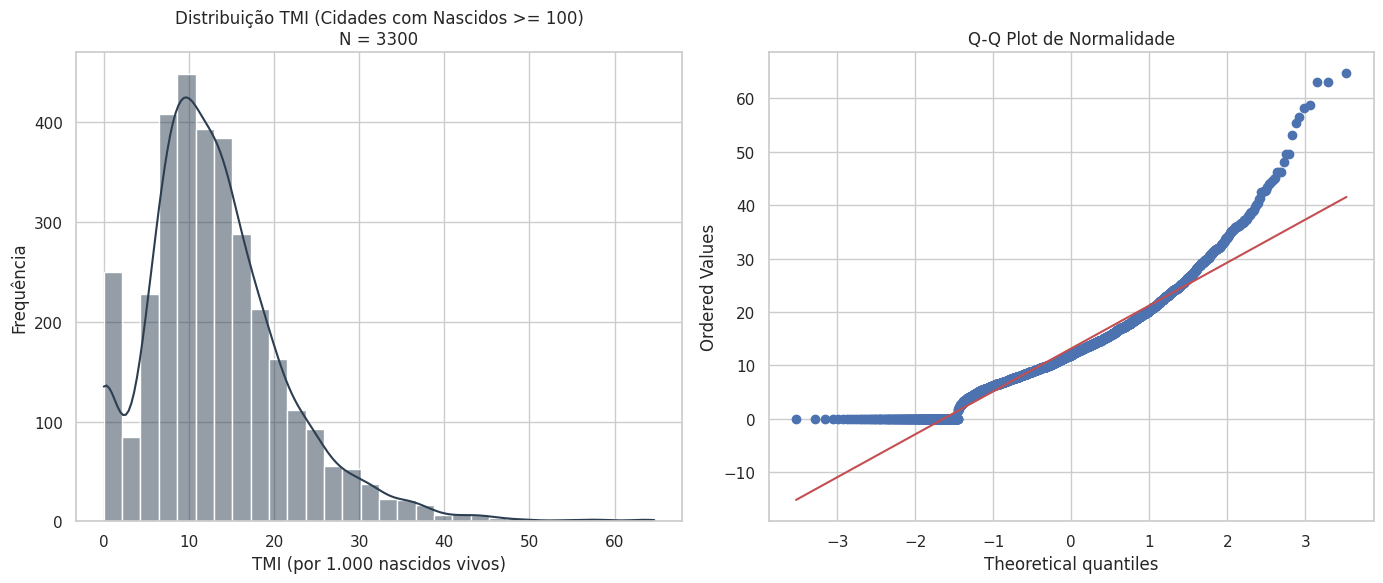


RESULTADOS DOS TESTES DE NORMALIDADE (df_clean)
1. D'Agostino K^2:     p-valor = 3.3460e-161
2. Kolmogorov-Smirnov: p-valor = 8.4852e-18
3. Shapiro-Wilk:       p-valor = 3.7876e-36
------------------------------------------------------------
CONCLUSÃO (a 10.0%): REJEITA-SE a Hipótese Nula.
A distribuição NÃO é estatisticamente normal.
Obs: Isso é esperado em dados reais de saúde. O formato visual 'de sino' é o mais importante para o PCA.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# --- 1. VISUALIZAÇÃO GRÁFICA ---
fig, ax = plt.subplots(1, 2)

# Gráfico da Esquerda: Histograma + KDE (Densidade)
sns.histplot(df_clean['TMI'], kde=True, ax=ax[0], color='#2c3e50', bins=30)
ax[0].set_title(f'Distribuição TMI (Cidades com Nascidos >= 100)\nN = {len(df_clean)}')
ax[0].set_xlabel('TMI (por 1.000 nascidos vivos)')
ax[0].set_ylabel('Frequência')

# Gráfico da Direita: Q-Q Plot (Teste Visual de Normalidade)
# Se os pontos seguirem a linha vermelha, é normal.
stats.probplot(df_clean['TMI'], dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot de Normalidade')

plt.tight_layout()
plt.show()

# --- 2. TESTES ESTATÍSTICOS DE NORMALIDADE (Alpha = 10%) ---
print("\n" + "="*60)
print("RESULTADOS DOS TESTES DE NORMALIDADE (df_clean)")
print("="*60)

# Pegando os dados válidos
dados = df_clean['TMI'].dropna()

# Teste 1: D'Agostino-Pearson K^2 (Mais robusto para N > 50)
k2, p_k2 = stats.normaltest(dados)

# Teste 2: Kolmogorov-Smirnov (KS)
# Padronizando os dados (Z-score) para comparar com a normal padrão
dados_z = (dados - dados.mean()) / dados.std()
ks_stat, p_ks = stats.kstest(dados_z, 'norm')

# Teste 3: Shapiro-Wilk (Clássico, mas muito rigoroso)
shapiro_stat, p_shapiro = stats.shapiro(dados)

print(f"1. D'Agostino K^2:     p-valor = {p_k2:.4e}")
print(f"2. Kolmogorov-Smirnov: p-valor = {p_ks:.4e}")
print(f"3. Shapiro-Wilk:       p-valor = {p_shapiro:.4e}")

print("-" * 60)
alpha = 0.10

# Lógica de decisão
if p_k2 < alpha:
    print(f"CONCLUSÃO (a {alpha*100}%): REJEITA-SE a Hipótese Nula.")
    print("A distribuição NÃO é estatisticamente normal.")
    print("Obs: Isso é esperado em dados reais de saúde. O formato visual 'de sino' é o mais importante para o PCA.")
else:
    print(f"CONCLUSÃO (a {alpha*100}%): FALHA EM REJEITAR a Hipótese Nula.")
    print("A distribuição pode ser considerada normal.")

In [13]:
# Salvando o DataFrame principal
# index=False evita criar aquela coluna "Unnamed: 0" quando carregar de volta
df_tmi.to_parquet('tmi_municipios_2022.parquet', index=False)

print("Arquivo 'tmi_municipios_2022.parquet' salvo com sucesso!")

Arquivo 'tmi_municipios_2022.parquet' salvo com sucesso!


###################################mudando para 2023######################################


In [20]:
import pandas as pd

# Carrega o arquivo (ajuste o caminho se estiver em uma subpasta)
df_sim = pd.read_parquet('data/processed/sim_2023_unificado.parquet')

# Opção 1: Listar apenas os nomes das colunas (bom para copiar e colar)
print("Lista de Colunas:")
print(df_sim.columns.tolist())

# Opção 2: Ver nomes, tipos de dados e contagem de nulos (Melhor para diagnóstico)
print("\nInformações do DataFrame:")
df_sim.info()

# Opção 3: Ver as primeiras linhas para entender o conteúdo
display(df_sim.head())

Lista de Colunas:
['TIPOBITO', 'DTOBITO', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'CODMUNRES', 'CIRCOBITO', 'CAUSABAS']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465610 entries, 0 to 1465609
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   TIPOBITO   1465610 non-null  object
 1   DTOBITO    1465610 non-null  object
 2   IDADE      1465610 non-null  object
 3   SEXO       1465610 non-null  object
 4   RACACOR    1465610 non-null  object
 5   ESC2010    1465610 non-null  object
 6   CODMUNRES  1465610 non-null  object
 7   CIRCOBITO  1465610 non-null  object
 8   CAUSABAS   1465610 non-null  object
dtypes: object(9)
memory usage: 100.6+ MB


,TIPOBITO,DTOBITO,IDADE,SEXO,RACACOR,ESC2010,CODMUNRES,CIRCOBITO,CAUSABAS
0,2,01012023,477,2,4,5,250750,,G309
1,2,01012023,465,2,1,1,250750,,C700
2,2,01012023,481,2,1,0,251130,,I64
3,2,01012023,466,2,4,2,251100,,N179
4,2,01012023,468,2,1,1,251130,,A419


In [21]:
#Agora vamos pegar o numerador da TMI para 2022
# 1. Filtrar apenas óbitos NÃO fetais
obitos_vivos = df_sim[df_sim['TIPOBITO'] == '2'].copy()

# 2. Converter IDADE para string para ler o primeiro dígito
# O dicionário diz que unidades 0, 1, 2 e 3 são menores de 1 ano
# 0=minutos, 1=horas, 2=dias, 3=meses
obitos_infantis = obitos_vivos[
    obitos_vivos['IDADE'].astype(str).str[0].isin(['0', '1', '2', '3'])
]

# 3. Agrupar por Município de Residência
tmi_numerador = obitos_infantis.groupby('CODMUNRES').size().reset_index(name='obitos_menores_1ano')

# Visualizar
display(tmi_numerador.head())

,CODMUNRES,obitos_menores_1ano
0,110001,4
1,110002,19
2,110004,12
3,110006,2
4,110007,1


In [22]:
import pandas as pd

# Carregando o arquivo (assumindo que o separador é vírgula conforme seu snippet)
# Se der erro de encoding, tente 'latin1'
df = pd.read_csv('data/nascidos_vivos/nascidos_vivos_2023.csv', encoding='latin1', sep=',')

# 1. Renomeando para facilitar a manipulação
# O nome original 'MunicÃ­pio' sugere erro de encoding na origem, vamos padronizar
df.columns = ['Municipio_Completo', 'Nascidos']

# 2. Filtrando: Removemos qualquer linha que contenha "IGNORADO"
# O til (~) inverte a condição, ou seja, "pegue tudo que NÃO contém IGNORADO"
df_clean = df[~df['Municipio_Completo'].str.contains('IGNORADO', na=False)].copy()

# 3. Separando Código e Nome
# O padrão é "110001 ALTA FLORESTA D'OESTE" (Código + Espaço + Nome)
# Usamos o split com n=1 para separar apenas no primeiro espaço
df_clean[['Codigo_IBGE', 'Nome_Municipio']] = df_clean['Municipio_Completo'].str.split(' ', n=1, expand=True)

# 4. Organizando o DataFrame final
df_final = df_clean[['Codigo_IBGE', 'Nome_Municipio', 'Nascidos']]

# Visualizando o resultado
print("Visualização Limpa:")
display(df_final.head())

Visualização Limpa:


,Codigo_IBGE,Nome_Municipio,Nascidos
1,110001,ALTA FLORESTA D'OESTE,383.0
2,110002,ARIQUEMES,1515.0
3,110003,CABIXI,77.0
4,110004,CACOAL,1343.0
5,110005,CEREJEIRAS,280.0


In [23]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. PREPARAÇÃO DO NUMERADOR (SIM - Óbitos)
# ==============================================================================
# Critérios:
# - TIPOBITO == '2' (Não Fetal)
# - IDADE começando com 0 (min), 1 (horas), 2 (dias), 3 (meses)

# Garante que as colunas críticas sejam string para manipulação
df_sim['TIPOBITO'] = df_sim['TIPOBITO'].astype(str)
df_sim['IDADE'] = df_sim['IDADE'].astype(str).str.zfill(3) # Garante 3 dígitos (ex: '025')
df_sim['CODMUNRES'] = df_sim['CODMUNRES'].astype(str)

# Filtro
mask_infantil = (
    (df_sim['TIPOBITO'] == '2') & 
    (df_sim['IDADE'].str[0].isin(['0', '1', '2', '3']))
)

# Agrupamento
# Nota: O SIM geralmente usa 7 dígitos. O comando .str[:6] padroniza para 6.
df_obitos = (
    df_sim[mask_infantil]
    .groupby(df_sim['CODMUNRES'].str[:6])
    .size()
    .reset_index(name='Obitos_Infantis')
    .rename(columns={'CODMUNRES': 'Codigo_IBGE'}) # Renomeia para facilitar o merge
)

# ==============================================================================
# 2. PREPARAÇÃO DO DENOMINADOR (SINASC - Nascidos Vivos)
# ==============================================================================
# Supondo que df_final seja o dataframe limpo do passo anterior
# Colunas esperadas: 'Codigo_IBGE', 'Nascidos'

df_nascidos = df_final.copy()

# Garantia de Tipagem e Padronização (6 dígitos)
df_nascidos['Codigo_IBGE'] = df_nascidos['Codigo_IBGE'].astype(str).str[:6]
df_nascidos['Nascidos'] = pd.to_numeric(df_nascidos['Nascidos'], errors='coerce').fillna(0)

# Agrupa por segurança (caso haja linhas duplicadas do mesmo município)
df_nascidos = (
    df_nascidos
    .groupby('Codigo_IBGE')['Nascidos']
    .sum()
    .reset_index()
)

# ==============================================================================
# 3. MERGE E CÁLCULO (O "Pulo do Gato")
# ==============================================================================

# Left Join: Mantém todos os municípios que tiveram nascimentos
df_tmi = pd.merge(df_nascidos, df_obitos, on='Codigo_IBGE', how='left')

# Preenche com 0 onde não houve óbito (NaN -> 0)
df_tmi['Obitos_Infantis'] = df_tmi['Obitos_Infantis'].fillna(0)

# Cálculo da Taxa
# Fórmula: (Óbitos < 1 ano / Nascidos Vivos) * 1.000
df_tmi['TMI'] = (df_tmi['Obitos_Infantis'] / df_tmi['Nascidos']) * 1000

# ==============================================================================
# 4. LIMPEZA ESTATÍSTICA (Para seu PCA)
# ==============================================================================

# Tratando divisões por zero (infinito)
# Se Nascidos = 0 e Obitos > 0 -> Infinito (Erro de registro temporal)
# Se Nascidos = 0 e Obitos = 0 -> NaN (Indefinido)
df_tmi.replace([np.inf, -np.inf], np.nan, inplace=True)

# Visualização Final
print("Resumo Estatístico da TMI:")
print(df_tmi['TMI'].describe())

print("\nTop 5 Municípios com maiores TMIs (Checagem de Outliers):")
display(df_tmi.sort_values('TMI', ascending=False).head())

# Dica: Para o PCA, considere remover municípios com TMI NaN
# df_pca = df_tmi.dropna(subset=['TMI'])

Resumo Estatístico da TMI:
count    5570.000000
mean       12.941656
std        13.236583
min         0.000000
25%         0.000000
50%        11.213458
75%        18.292683
max       153.846154
Name: TMI, dtype: float64

Top 5 Municípios com maiores TMIs (Checagem de Outliers):


,Codigo_IBGE,Nascidos,Obitos_Infantis,TMI
5290,510729,13.0,2.0,153.846154
3796,354740,14.0,2.0,142.857143
1227,241380,22.0,3.0,136.363636
4967,431673,15.0,2.0,133.333333
1377,251070,35.0,4.0,114.285714


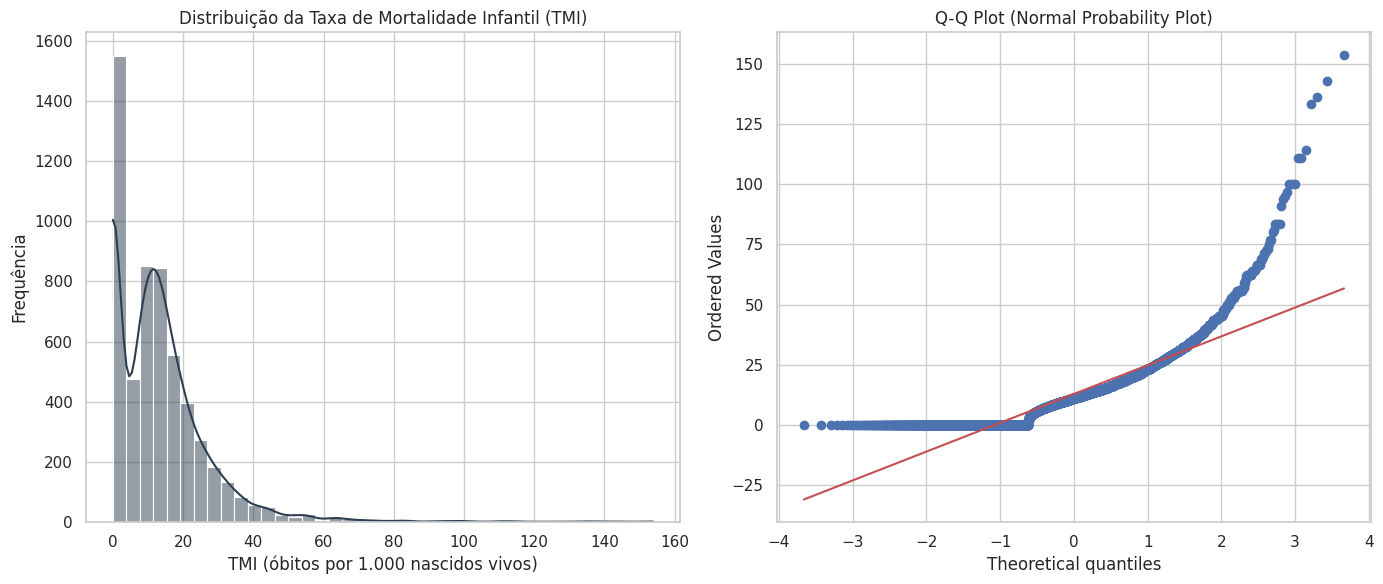


=== Testes de Normalidade (Alpha = 0.10) ===
Teste D'Agostino K²: p-valor = 0.0000e+00
Teste Kolmogorov-Smirnov: p-valor = 1.4924e-131

CONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuração do estilo para publicação
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: Histograma + KDE (Distribuição) ---
plt.subplot(1, 2, 1)
# O 'histplot' mostra a frequência real, o 'kde' a curva suave estimada
sns.histplot(df_tmi['TMI'].dropna(), kde=True, color='#2c3e50', bins=40)
plt.title('Distribuição da Taxa de Mortalidade Infantil (TMI)', fontsize=12)
plt.xlabel('TMI (óbitos por 1.000 nascidos vivos)')
plt.ylabel('Frequência')

# --- GRÁFICO 2: Q-Q Plot (Normalidade) ---
plt.subplot(1, 2, 2)
# Compara os quantis da sua TMI com os quantis teóricos de uma Normal
stats.probplot(df_tmi['TMI'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Normal Probability Plot)', fontsize=12)

plt.tight_layout()
plt.show()

# --- TESTES DE HIPÓTESES (Alpha = 10%) ---
print("\n=== Testes de Normalidade (Alpha = 0.10) ===")
dados_validos = df_tmi['TMI'].dropna()

# 1. Teste de D'Agostino-Pearson (Baseado em Assimetria e Curtose) - Recomendado para N grande
stat_k2, p_k2 = stats.normaltest(dados_validos)
print(f"Teste D'Agostino K²: p-valor = {p_k2:.4e}")

# 2. Teste de Kolmogorov-Smirnov (Comparação de CDFs)
# Normalizamos os dados para comparar com a normal padrão (0,1)
stat_ks, p_ks = stats.kstest((dados_validos - dados_validos.mean())/dados_validos.std(), 'norm')
print(f"Teste Kolmogorov-Smirnov: p-valor = {p_ks:.4e}")

# Conclusão Automática
alpha = 0.10
if p_k2 < alpha:
    print(f"\nCONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.")
else:
    print(f"\nCONCLUSÃO: Falhamos em rejeitar H0. A distribuição pode ser normal.")

In [25]:
# Salvando o DataFrame principal
# index=False evita criar aquela coluna "Unnamed: 0" quando carregar de volta
df_tmi.to_parquet('tmi_municipios_2023.parquet', index=False)

print("Arquivo 'tmi_municipios_2023.parquet' salvo com sucesso!")

Arquivo 'tmi_municipios_2023.parquet' salvo com sucesso!


#######################################2023#########################################

In [26]:
import pandas as pd

# Carrega o arquivo (ajuste o caminho se estiver em uma subpasta)
df_sim = pd.read_parquet('data/processed/sim_2024_unificado.parquet')

# Opção 1: Listar apenas os nomes das colunas (bom para copiar e colar)
print("Lista de Colunas:")
print(df_sim.columns.tolist())

# Opção 2: Ver nomes, tipos de dados e contagem de nulos (Melhor para diagnóstico)
print("\nInformações do DataFrame:")
df_sim.info()

# Opção 3: Ver as primeiras linhas para entender o conteúdo
display(df_sim.head())

Lista de Colunas:
['TIPOBITO', 'DTOBITO', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'CODMUNRES', 'CIRCOBITO', 'CAUSABAS']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532015 entries, 0 to 1532014
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   TIPOBITO   1532015 non-null  object
 1   DTOBITO    1532015 non-null  object
 2   IDADE      1532015 non-null  object
 3   SEXO       1532015 non-null  object
 4   RACACOR    1532015 non-null  object
 5   ESC2010    1532015 non-null  object
 6   CODMUNRES  1532015 non-null  object
 7   CIRCOBITO  1532015 non-null  object
 8   CAUSABAS   1532015 non-null  object
dtypes: object(9)
memory usage: 105.2+ MB


,TIPOBITO,DTOBITO,IDADE,SEXO,RACACOR,ESC2010,CODMUNRES,CIRCOBITO,CAUSABAS
0,2,01012024,488,1,4,1,500110,,J159
1,2,01012024,472,2,1,1,500060,,C56
2,2,01012024,484,2,1,3,500370,1,W019
3,2,01012024,101,2,5,,500370,,P968
4,2,01012024,466,1,5,0,500480,,A162


In [27]:
#Agora vamos pegar o numerador da TMI para 2022
# 1. Filtrar apenas óbitos NÃO fetais
obitos_vivos = df_sim[df_sim['TIPOBITO'] == '2'].copy()

# 2. Converter IDADE para string para ler o primeiro dígito
# O dicionário diz que unidades 0, 1, 2 e 3 são menores de 1 ano
# 0=minutos, 1=horas, 2=dias, 3=meses
obitos_infantis = obitos_vivos[
    obitos_vivos['IDADE'].astype(str).str[0].isin(['0', '1', '2', '3'])
]

# 3. Agrupar por Município de Residência
tmi_numerador = obitos_infantis.groupby('CODMUNRES').size().reset_index(name='obitos_menores_1ano')

# Visualizar
display(tmi_numerador.head())

,CODMUNRES,obitos_menores_1ano
0,110001,3
1,110002,19
2,110004,11
3,110005,3
4,110006,7


In [28]:
import pandas as pd

# Carregando o arquivo (assumindo que o separador é vírgula conforme seu snippet)
# Se der erro de encoding, tente 'latin1'
df = pd.read_csv('data/nascidos_vivos/nascidos_vivos_2024.csv', encoding='latin1', sep=',')

# 1. Renomeando para facilitar a manipulação
# O nome original 'MunicÃ­pio' sugere erro de encoding na origem, vamos padronizar
df.columns = ['Municipio_Completo', 'Nascidos']

# 2. Filtrando: Removemos qualquer linha que contenha "IGNORADO"
# O til (~) inverte a condição, ou seja, "pegue tudo que NÃO contém IGNORADO"
df_clean = df[~df['Municipio_Completo'].str.contains('IGNORADO', na=False)].copy()

# 3. Separando Código e Nome
# O padrão é "110001 ALTA FLORESTA D'OESTE" (Código + Espaço + Nome)
# Usamos o split com n=1 para separar apenas no primeiro espaço
df_clean[['Codigo_IBGE', 'Nome_Municipio']] = df_clean['Municipio_Completo'].str.split(' ', n=1, expand=True)

# 4. Organizando o DataFrame final
df_final = df_clean[['Codigo_IBGE', 'Nome_Municipio', 'Nascidos']]

# Visualizando o resultado
print("Visualização Limpa:")
display(df_final.head())

Visualização Limpa:


,Codigo_IBGE,Nome_Municipio,Nascidos
0,110001,ALTA FLORESTA D'OESTE,293.0
1,110002,ARIQUEMES,1364.0
2,110003,CABIXI,60.0
3,110004,CACOAL,1258.0
4,110005,CEREJEIRAS,236.0


In [29]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. PREPARAÇÃO DO NUMERADOR (SIM - Óbitos)
# ==============================================================================
# Critérios:
# - TIPOBITO == '2' (Não Fetal)
# - IDADE começando com 0 (min), 1 (horas), 2 (dias), 3 (meses)

# Garante que as colunas críticas sejam string para manipulação
df_sim['TIPOBITO'] = df_sim['TIPOBITO'].astype(str)
df_sim['IDADE'] = df_sim['IDADE'].astype(str).str.zfill(3) # Garante 3 dígitos (ex: '025')
df_sim['CODMUNRES'] = df_sim['CODMUNRES'].astype(str)

# Filtro
mask_infantil = (
    (df_sim['TIPOBITO'] == '2') & 
    (df_sim['IDADE'].str[0].isin(['0', '1', '2', '3']))
)

# Agrupamento
# Nota: O SIM geralmente usa 7 dígitos. O comando .str[:6] padroniza para 6.
df_obitos = (
    df_sim[mask_infantil]
    .groupby(df_sim['CODMUNRES'].str[:6])
    .size()
    .reset_index(name='Obitos_Infantis')
    .rename(columns={'CODMUNRES': 'Codigo_IBGE'}) # Renomeia para facilitar o merge
)

# ==============================================================================
# 2. PREPARAÇÃO DO DENOMINADOR (SINASC - Nascidos Vivos)
# ==============================================================================
# Supondo que df_final seja o dataframe limpo do passo anterior
# Colunas esperadas: 'Codigo_IBGE', 'Nascidos'

df_nascidos = df_final.copy()

# Garantia de Tipagem e Padronização (6 dígitos)
df_nascidos['Codigo_IBGE'] = df_nascidos['Codigo_IBGE'].astype(str).str[:6]
df_nascidos['Nascidos'] = pd.to_numeric(df_nascidos['Nascidos'], errors='coerce').fillna(0)

# Agrupa por segurança (caso haja linhas duplicadas do mesmo município)
df_nascidos = (
    df_nascidos
    .groupby('Codigo_IBGE')['Nascidos']
    .sum()
    .reset_index()
)

# ==============================================================================
# 3. MERGE E CÁLCULO (O "Pulo do Gato")
# ==============================================================================

# Left Join: Mantém todos os municípios que tiveram nascimentos
df_tmi = pd.merge(df_nascidos, df_obitos, on='Codigo_IBGE', how='left')

# Preenche com 0 onde não houve óbito (NaN -> 0)
df_tmi['Obitos_Infantis'] = df_tmi['Obitos_Infantis'].fillna(0)

# Cálculo da Taxa
# Fórmula: (Óbitos < 1 ano / Nascidos Vivos) * 1.000
df_tmi['TMI'] = (df_tmi['Obitos_Infantis'] / df_tmi['Nascidos']) * 1000

# ==============================================================================
# 4. LIMPEZA ESTATÍSTICA (Para seu PCA)
# ==============================================================================

# Tratando divisões por zero (infinito)
# Se Nascidos = 0 e Obitos > 0 -> Infinito (Erro de registro temporal)
# Se Nascidos = 0 e Obitos = 0 -> NaN (Indefinido)
df_tmi.replace([np.inf, -np.inf], np.nan, inplace=True)

# Visualização Final
print("Resumo Estatístico da TMI:")
print(df_tmi['TMI'].describe())

print("\nTop 5 Municípios com maiores TMIs (Checagem de Outliers):")
display(df_tmi.sort_values('TMI', ascending=False).head())

# Dica: Para o PCA, considere remover municípios com TMI NaN
# df_pca = df_tmi.dropna(subset=['TMI'])

Resumo Estatístico da TMI:
count    5571.000000
mean       12.759811
std        13.902594
min         0.000000
25%         0.000000
50%        10.989011
75%        17.857143
max       250.000000
Name: TMI, dtype: float64

Top 5 Municípios com maiores TMIs (Checagem de Outliers):


,Codigo_IBGE,Nascidos,Obitos_Infantis,TMI
3349,350720,4.0,1.0,250.000000
3638,353286,5.0,1.0,200.000000
5340,520120,7.0,1.0,142.857143
4912,431413,21.0,3.0,142.857143
4973,431697,25.0,3.0,120.000000


In [30]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. PREPARAÇÃO DO NUMERADOR (SIM - Óbitos)
# ==============================================================================
# Critérios:
# - TIPOBITO == '2' (Não Fetal)
# - IDADE começando com 0 (min), 1 (horas), 2 (dias), 3 (meses)

# Garante que as colunas críticas sejam string para manipulação
df_sim['TIPOBITO'] = df_sim['TIPOBITO'].astype(str)
df_sim['IDADE'] = df_sim['IDADE'].astype(str).str.zfill(3) # Garante 3 dígitos (ex: '025')
df_sim['CODMUNRES'] = df_sim['CODMUNRES'].astype(str)

# Filtro
mask_infantil = (
    (df_sim['TIPOBITO'] == '2') & 
    (df_sim['IDADE'].str[0].isin(['0', '1', '2', '3']))
)

# Agrupamento
# Nota: O SIM geralmente usa 7 dígitos. O comando .str[:6] padroniza para 6.
df_obitos = (
    df_sim[mask_infantil]
    .groupby(df_sim['CODMUNRES'].str[:6])
    .size()
    .reset_index(name='Obitos_Infantis')
    .rename(columns={'CODMUNRES': 'Codigo_IBGE'}) # Renomeia para facilitar o merge
)

# ==============================================================================
# 2. PREPARAÇÃO DO DENOMINADOR (SINASC - Nascidos Vivos)
# ==============================================================================
# Supondo que df_final seja o dataframe limpo do passo anterior
# Colunas esperadas: 'Codigo_IBGE', 'Nascidos'

df_nascidos = df_final.copy()

# Garantia de Tipagem e Padronização (6 dígitos)
df_nascidos['Codigo_IBGE'] = df_nascidos['Codigo_IBGE'].astype(str).str[:6]
df_nascidos['Nascidos'] = pd.to_numeric(df_nascidos['Nascidos'], errors='coerce').fillna(0)

# Agrupa por segurança (caso haja linhas duplicadas do mesmo município)
df_nascidos = (
    df_nascidos
    .groupby('Codigo_IBGE')['Nascidos']
    .sum()
    .reset_index()
)

# ==============================================================================
# 3. MERGE E CÁLCULO (O "Pulo do Gato")
# ==============================================================================

# Left Join: Mantém todos os municípios que tiveram nascimentos
df_tmi = pd.merge(df_nascidos, df_obitos, on='Codigo_IBGE', how='left')

# Preenche com 0 onde não houve óbito (NaN -> 0)
df_tmi['Obitos_Infantis'] = df_tmi['Obitos_Infantis'].fillna(0)

# Cálculo da Taxa
# Fórmula: (Óbitos < 1 ano / Nascidos Vivos) * 1.000
df_tmi['TMI'] = (df_tmi['Obitos_Infantis'] / df_tmi['Nascidos']) * 1000

# ==============================================================================
# 4. LIMPEZA ESTATÍSTICA (Para seu PCA)
# ==============================================================================

# Tratando divisões por zero (infinito)
# Se Nascidos = 0 e Obitos > 0 -> Infinito (Erro de registro temporal)
# Se Nascidos = 0 e Obitos = 0 -> NaN (Indefinido)
df_tmi.replace([np.inf, -np.inf], np.nan, inplace=True)

# Visualização Final
print("Resumo Estatístico da TMI:")
print(df_tmi['TMI'].describe())

print("\nTop 5 Municípios com maiores TMIs (Checagem de Outliers):")
display(df_tmi.sort_values('TMI', ascending=False).head())

# Dica: Para o PCA, considere remover municípios com TMI NaN
# df_pca = df_tmi.dropna(subset=['TMI'])

Resumo Estatístico da TMI:
count    5571.000000
mean       12.759811
std        13.902594
min         0.000000
25%         0.000000
50%        10.989011
75%        17.857143
max       250.000000
Name: TMI, dtype: float64

Top 5 Municípios com maiores TMIs (Checagem de Outliers):


,Codigo_IBGE,Nascidos,Obitos_Infantis,TMI
3349,350720,4.0,1.0,250.000000
3638,353286,5.0,1.0,200.000000
5340,520120,7.0,1.0,142.857143
4912,431413,21.0,3.0,142.857143
4973,431697,25.0,3.0,120.000000


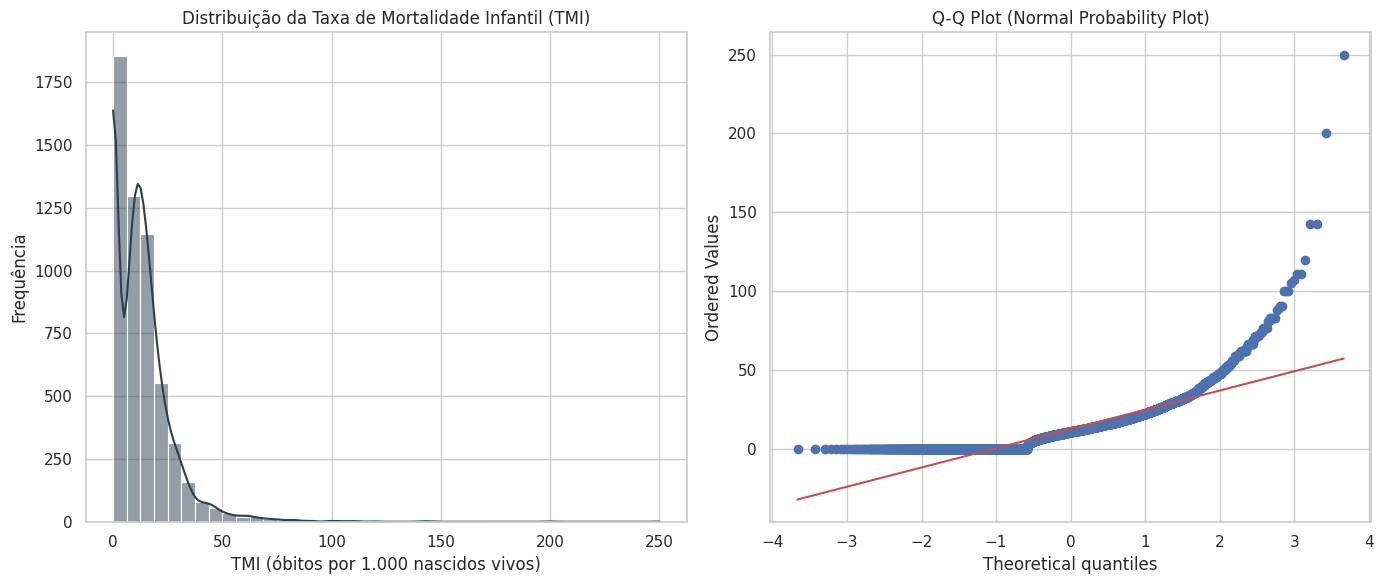


=== Testes de Normalidade (Alpha = 0.10) ===
Teste D'Agostino K²: p-valor = 0.0000e+00
Teste Kolmogorov-Smirnov: p-valor = 2.8311e-157

CONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuração do estilo para publicação
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: Histograma + KDE (Distribuição) ---
plt.subplot(1, 2, 1)
# O 'histplot' mostra a frequência real, o 'kde' a curva suave estimada
sns.histplot(df_tmi['TMI'].dropna(), kde=True, color='#2c3e50', bins=40)
plt.title('Distribuição da Taxa de Mortalidade Infantil (TMI)', fontsize=12)
plt.xlabel('TMI (óbitos por 1.000 nascidos vivos)')
plt.ylabel('Frequência')

# --- GRÁFICO 2: Q-Q Plot (Normalidade) ---
plt.subplot(1, 2, 2)
# Compara os quantis da sua TMI com os quantis teóricos de uma Normal
stats.probplot(df_tmi['TMI'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Normal Probability Plot)', fontsize=12)

plt.tight_layout()
plt.show()

# --- TESTES DE HIPÓTESES (Alpha = 10%) ---
print("\n=== Testes de Normalidade (Alpha = 0.10) ===")
dados_validos = df_tmi['TMI'].dropna()

# 1. Teste de D'Agostino-Pearson (Baseado em Assimetria e Curtose) - Recomendado para N grande
stat_k2, p_k2 = stats.normaltest(dados_validos)
print(f"Teste D'Agostino K²: p-valor = {p_k2:.4e}")

# 2. Teste de Kolmogorov-Smirnov (Comparação de CDFs)
# Normalizamos os dados para comparar com a normal padrão (0,1)
stat_ks, p_ks = stats.kstest((dados_validos - dados_validos.mean())/dados_validos.std(), 'norm')
print(f"Teste Kolmogorov-Smirnov: p-valor = {p_ks:.4e}")

# Conclusão Automática
alpha = 0.10
if p_k2 < alpha:
    print(f"\nCONCLUSÃO: Rejeitamos H0. A distribuição NÃO segue uma normal.")
else:
    print(f"\nCONCLUSÃO: Falhamos em rejeitar H0. A distribuição pode ser normal.")

In [32]:
# Salvando o DataFrame principal
# index=False evita criar aquela coluna "Unnamed: 0" quando carregar de volta
df_tmi.to_parquet('tmi_municipios_2024.parquet', index=False)

print("Arquivo 'tmi_municipios_2024.parquet' salvo com sucesso!")

Arquivo 'tmi_municipios_2024.parquet' salvo com sucesso!


In [44]:
# Filtrando Causas Externas (Capítulo XX do CID-10: V, W, X, Y)
# O regex '^[V-Y]' pega tudo que começa com V, W, X ou Y
mask_externas = df_sim['CAUSABAS'].astype(str).str.match(r'^[V-Y]')

# Agrupando por Município (Padronizando para 6 dígitos)
df_causas_externas = (
    df_sim[mask_externas]
    .groupby(df_sim['CODMUNRES'].astype(str).str[:6])
    .size()
    .reset_index(name='Obitos_Causas_Externas')
    .rename(columns={'CODMUNRES': 'Codigo_IBGE'})
)

print("Resumo dos Óbitos por Causas Externas:")
display(df_causas_externas.head())

Resumo dos Óbitos por Causas Externas:


,Codigo_IBGE,Obitos_Causas_Externas
0,110000,13
1,110001,24
2,110002,111
3,110003,2
4,110004,76


In [57]:
import pandas as pd

# 1. Carrega do zero (para garantir que não pegue colunas criadas anteriormente)
df_pop = pd.read_csv('data/pop_2024.csv', sep=',', encoding='latin1', engine='python')

# 2. Identifica as colunas automaticamente pelo nome
# Procura colunas que tenham 'UF', 'MUNIC' (código) e 'POP' no nome
col_cod_uf = [c for c in df_pop.columns if 'COD' in c.upper() and 'UF' in c.upper()][0]
col_cod_mun = [c for c in df_pop.columns if 'COD' in c.upper() and 'MUNIC' in c.upper()][0]
col_populacao = [c for c in df_pop.columns if 'POP' in c.upper()][0]

print(f"Colunas identificadas:\nUF: {col_cod_uf}\nMun: {col_cod_mun}\nPop: {col_populacao}")

# 3. Cria o ID (UF + Município)
# Força string e preenche zeros
df_pop['ID'] = (
    df_pop[col_cod_uf].astype(str).str.split('.').str[0] + 
    df_pop[col_cod_mun].astype(str).str.split('.').str[0].str.zfill(5)
).str[:6]

# 4. Limpa a População (Usando a coluna identificada pelo nome)
# Remove parenteses (notas de rodapé) e pontos
pop_str = df_pop[col_populacao].astype(str).str.split('(').str[0].str.replace('.', '', regex=False)
df_pop['pop'] = pd.to_numeric(pop_str, errors='coerce').astype('Int64') # Int64 aceita NaN se houver erro

# 5. Resultado Final
df_final = df_pop[['ID', 'pop']].dropna()
display(df_final.head())

Colunas identificadas:
UF: COD. UF
Mun: COD. MUNIC
Pop: POPULAÃÃO ESTIMADA


,ID,pop
0,110001,22853
1,110002,108573
2,110003,5690
3,110004,97637
4,110005,16975


In [58]:
import pandas as pd

# Supondo que df_final (População) e df_causas_externas (Óbitos) já estejam na memória

# 1. Padronizar nomes para o Merge
# O df_final tem coluna 'ID', vamos renomear para ficar igual ao do SIM
df_pop_ready = df_final.rename(columns={'ID': 'Codigo_IBGE'})

# 2. Cruzamento (Merge)
# Usamos 'left' para manter todos os municípios da base de população.
# Se um município não estiver na base de óbitos, ele virá como NaN (o que significa 0 óbitos).
df_taxa = pd.merge(df_pop_ready, df_causas_externas, on='Codigo_IBGE', how='left')

# 3. Limpeza de Nulos
# NaN nos óbitos vira 0 (nenhuma morte registrada)
df_taxa['Obitos_Causas_Externas'] = df_taxa['Obitos_Causas_Externas'].fillna(0)

# 4. Cálculo da Taxa (por 1.000 habitantes)
df_taxa['Taxa_Causas_Externas'] = (df_taxa['Obitos_Causas_Externas'] / df_taxa['pop']) * 1000

# 5. Validação Rápida
print("Top 5 Municípios com maior taxa de mortalidade por causas externas:")
display(df_taxa.sort_values('Taxa_Causas_Externas', ascending=False).head())

# 6. Salvar em Parquet
arquivo_saida = 'taxa_mortalidade_externa_2024.parquet'
df_taxa.to_parquet(arquivo_saida, index=False)
print(f"Arquivo '{arquivo_saida}' salvo com sucesso!")

Top 5 Municípios com maior taxa de mortalidade por causas externas:


,Codigo_IBGE,pop,Obitos_Causas_Externas,Taxa_Causas_Externas
336,170360,2016,8.0,3.968254
5229,510395,2899,10.0,3.449465
2482,312150,3059,10.0,3.269042
4000,410657,4171,13.0,3.116759
4260,412545,4030,12.0,2.977667


Arquivo 'taxa_mortalidade_externa_2024.parquet' salvo com sucesso!


#################2023####################

In [62]:
import pandas as pd
df_novo = pd.read_csv('data/pop_censo_2022.csv', encoding='latin1', sep=',')
df_novo

,Municipio,Codigo,Total
0,Alta Floresta D'Oeste,1 100 015,21 494
1,Ariquemes,1 100 023,96 833
2,Cabixi,1 100 031,5 351
3,Cacoal,1 100 049,86 887
4,Cerejeiras,1 100 056,15 890
...,...,...,...
5566,VicentinÃ³polis,5 222 054,8 768
5567,Vila Boa,5 222 203,4 215
5568,Vila PropÃ­cio,5 222 302,5 815
5569,BrasÃ­lia,5 300 108,2 817 381


In [65]:
# Transforma em string e pega apenas os 6 primeiros caracteres
df_novo[1] = df_novo[1].astype(str).str[:6]

# Agora você pode usar esse 'Codigo_IBGE' para fazer o merge com o resto

KeyError: 1